In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score


**Creating Data set**

In [2]:
X, y = make_moons(n_samples = 600, noise=0.25, random_state = 42)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state= 42)

**Pre Pruning (Early Stopping)**

In [6]:
depths = list(range(1,15))
train_acc_pre = []
test_acc_pre = []

for d in depths:
    tree = DecisionTreeClassifier(
        max_depth = d,
        min_samples_leaf = 5,
        random_state = 42
    )
    tree.fit(X_train, y_train)

    train_acc_pre.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc_pre.append(accuracy_score(y_test, tree.predict(X_test)))

test_acc_pre

[0.8111111111111111,
 0.8888888888888888,
 0.8888888888888888,
 0.8888888888888888,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9]

**Post Pruning (Cost Complexity Pruning)**

In [7]:
full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train, y_train)

# compute training path 
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas #cost complexity pruning 
train_acc_post = []
test_acc_post = []

for alpha in ccp_alphas:
    pruned_tree = DecisionTreeClassifier(
        ccp_alpha = alpha,
        random_state = 42
    )
    pruned_tree.fit(X_train, y_train)
    train_acc_post.append(
        accuracy_score(y_train, pruned_tree.predict(X_train)))
    test_acc_post.append(
        accuracy_score(y_test, pruned_tree.predict(X_test)))
test_acc_post
    

[0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9111111111111111,
 0.9111111111111111,
 0.9,
 0.9055555555555556,
 0.8888888888888888,
 0.9,
 0.9,
 0.9055555555555556,
 0.8888888888888888,
 0.8611111111111112,
 0.8111111111111111,
 0.49444444444444446]

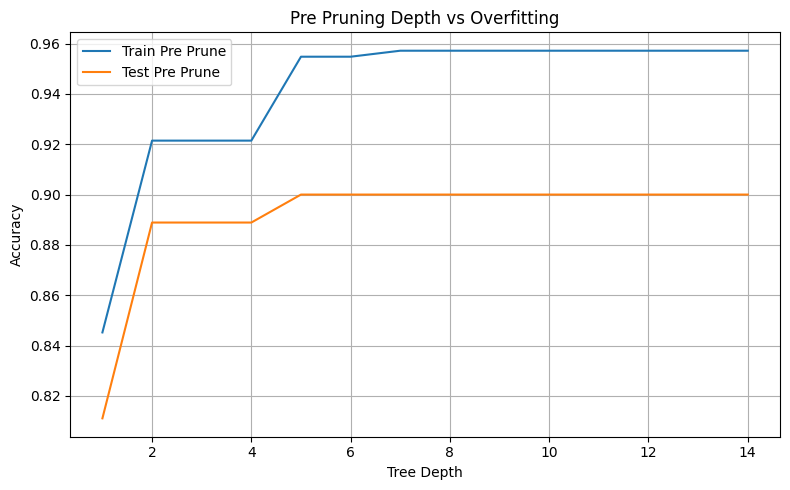

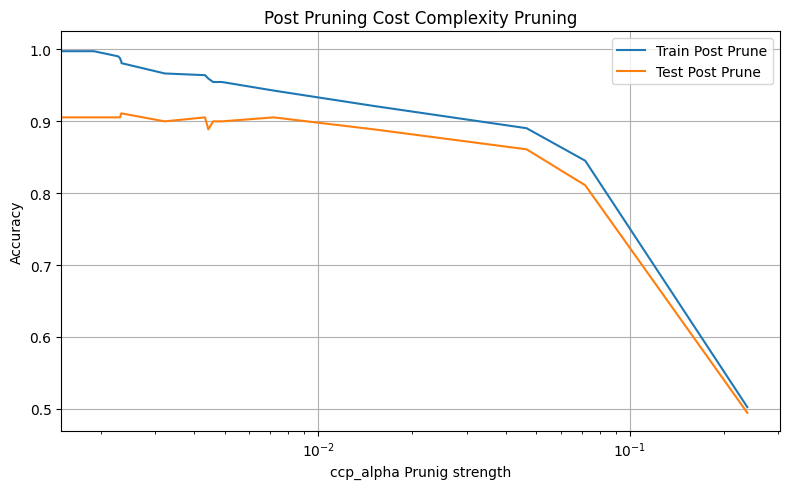

In [11]:
plt.figure(figsize =(8,5))
plt.plot(depths, train_acc_pre, label="Train Pre Prune")
plt.plot(depths, test_acc_pre, label="Test Pre Prune")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Pre Pruning Depth vs Overfitting")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize =(8,5))
plt.plot(ccp_alphas, train_acc_post, label="Train Post Prune")
plt.plot(ccp_alphas, test_acc_post, label="Test Post Prune")
plt.xscale("log")
plt.xlabel("ccp_alpha Prunig strength")
plt.ylabel("Accuracy")
plt.title("Post Pruning Cost Complexity Pruning")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()